In [ ]:
import os
from sklearn.model_selection import train_test_split
import shutil
import random
import time 
import copy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torchvision
from torchvision import datasets , models , transforms 
from torch.utils.data import DataLoader

from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

from torch import optim

import seaborn as sns

In [ ]:
base_folder = r'C:\Users\HP\Desktop\Dataset'  
dataset_folder = os.path.join(base_folder, 'Dataset')
new_folder = os.path.join(base_folder, 'data')

In [3]:
class_folders = [f for f in os.listdir(dataset_folder) if os.path.isdir(os.path.join(dataset_folder, f))]
class_folders

['Bacterial Spot',
 'Cercospora Leaf Spot',
 'Curl Virus',
 'Healthy Leaf',
 'Nutrition Deficiency',
 'White spot']

In [4]:
os.makedirs(new_folder, exist_ok=True)

In [5]:
for class_folder in class_folders:
    class_path = os.path.join(dataset_folder, class_folder)
    images = os.listdir(class_path)

    # Shuffle the images randomly
    random.shuffle(images)

    # Split the images into train, test, and validation sets
    train_images, temp_images = train_test_split(images, train_size=0.8, random_state=42)
    test_images, val_images = train_test_split(temp_images, train_size=0.5, random_state=42)

    # Create folders for train, test, and validation sets within the 'data' folder
    train_folder = os.path.join(new_folder, 'train', class_folder)
    test_folder = os.path.join(new_folder, 'test', class_folder)
    val_folder = os.path.join(new_folder, 'val', class_folder)

    os.makedirs(train_folder, exist_ok=True)
    os.makedirs(test_folder, exist_ok=True)
    os.makedirs(val_folder, exist_ok=True)

    # Move images to the respective folders
    for image in train_images:
        shutil.move(os.path.join(class_path, image), os.path.join(train_folder, image))

    for image in test_images:
        shutil.move(os.path.join(class_path, image), os.path.join(test_folder, image))

    for image in val_images:
        shutil.move(os.path.join(class_path, image), os.path.join(val_folder, image))


In [6]:
train_folder = os.path.join(new_folder, 'train')
num_total_train_images = sum(len(files) for _, _, files in os.walk(train_folder))

test_folder = os.path.join(new_folder, 'test')
num_total_test_images = sum(len(files) for _, _, files in os.walk(test_folder))

val_folder = os.path.join(new_folder, 'val')
num_total_val_images = sum(len(files) for _, _, files in os.walk(val_folder))

print(f"Total Train Images: {num_total_train_images}")
print(f"Total Test Images: {num_total_test_images}")
print(f"Total Validation Images: {num_total_val_images}")


Total Train Images: 1483
Total Test Images: 185
Total Validation Images: 188


# Data Loaders

In [7]:
mean_values = [0.485, 0.456, 0.406]
std_values = [0.229, 0.224, 0.225]

In [8]:
normalize = transforms.Normalize(mean=mean_values, std=std_values)

In [9]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(size=256, scale=(0.8, 1.0)),
    transforms.RandomRotation(30),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    normalize,
])

val_transforms = transforms.Compose([
    transforms.RandomResizedCrop(size=256, scale=(0.8, 1.0)),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    normalize,
])

test_transforms = transforms.Compose([
    transforms.RandomResizedCrop(size=256, scale=(0.8, 1.0)),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    normalize,
])

In [10]:
# Create custom dataset
train_dataset = datasets.ImageFolder(os.path.join(new_folder, 'train'), transform=train_transforms)
val_dataset = datasets.ImageFolder(os.path.join(new_folder, 'val'), transform=val_transforms)
test_dataset = datasets.ImageFolder(os.path.join(new_folder, 'test'), transform=test_transforms)

In [11]:
data_loaders = {x: DataLoader(
                    datasets.ImageFolder(os.path.join(new_folder, x),
                                         transform=train_transforms if x == 'train' else
                                                   val_transforms if x == 'val' else test_transforms),
                    batch_size=32,
                    shuffle=True if x == 'train' else False)
                for x in ['train', 'val', 'test']}

In [12]:
dataset_sizes = {x: len(datasets.ImageFolder(os.path.join(new_folder, x),
                 transform=train_transforms if x == 'train' else val_transforms if x == 'val' else test_transforms))
                 for x in ['train', 'val', 'test']}

class_names = datasets.ImageFolder(os.path.join(new_folder, 'train'), transform=train_transforms).classes

In [13]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [14]:
class_names, device , dataset_sizes

(['Bacterial Spot',
  'Cercospora Leaf Spot',
  'Curl Virus',
  'Healthy Leaf',
  'Nutrition Deficiency',
  'White spot'],
 device(type='cpu'),
 {'train': 1483, 'val': 188, 'test': 185})

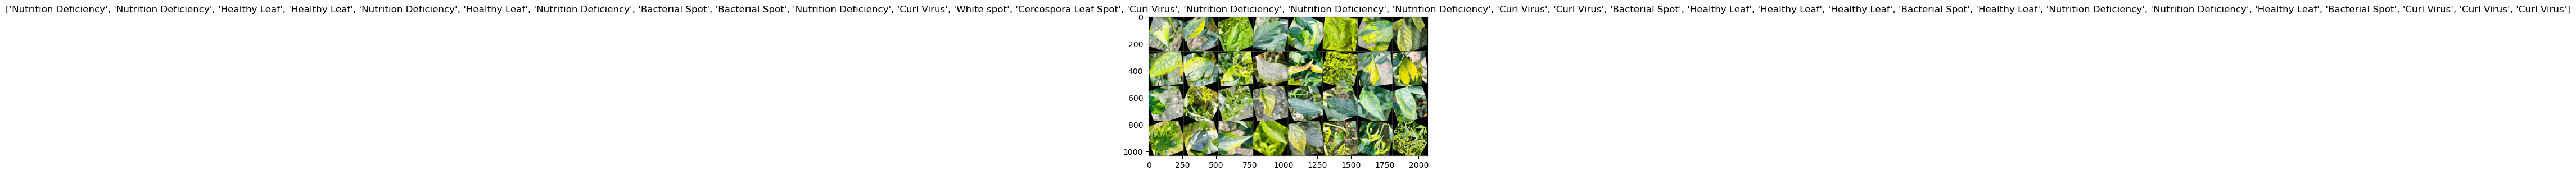

In [15]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

# Get a batch of training data from your data loader
inputs, classes = next(iter(data_loaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

# Display the grid using the modified imshow function
imshow(out, title=[class_names[x] for x in classes])

# Show the plot
plt.show()


In [16]:
help(models)

Help on package torchvision.models in torchvision:

NAME
    torchvision.models

PACKAGE CONTENTS
    _api
    _meta
    _utils
    alexnet
    convnext
    densenet
    detection (package)
    efficientnet
    feature_extraction
    googlenet
    inception
    maxvit
    mnasnet
    mobilenet
    mobilenetv2
    mobilenetv3
    optical_flow (package)
    quantization (package)
    regnet
    resnet
    segmentation (package)
    shufflenetv2
    squeezenet
    swin_transformer
    vgg
    video (package)
    vision_transformer

FILE
    c:\users\hp\anaconda3\lib\site-packages\torchvision\models\__init__.py




# VGG16

In [ ]:
model_ft = models.vgg16(pretrained=True)
model_ft

In [18]:
def count_params(model):
  model_params = {"Modules": list(), "Parameters": list()}
  total = {"trainable": 0, "non_trainable": 0}
  for name, parameters in model.named_parameters():
    param = parameters.numel()
    if not parameters.requires_grad:
      total["non_trainable"] += param
      continue
    model_params["Modules"].append(name)
    model_params["Parameters"].append(param)
    total["trainable"] += param
  df = pd.DataFrame(model_params)
  df = df.style.set_caption(f"Total parameters: {total}")
  return df

In [ ]:
count_params(model_ft)

In [20]:
for parameters in model_ft.parameters():
  parameters.requires_grad = False

In [ ]:
count_params(model_ft)

In [ ]:
model_ft.classifier

In [23]:
model_ft.classifier = nn.Sequential(
    nn.Linear(in_features=25088, out_features=100, bias=True),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.5, inplace=False),
    nn.Linear(in_features=100, out_features=6, bias=True)
)

In [ ]:
print(model_ft)

In [ ]:
count_params(model_ft)

In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_ft.parameters())

In [ ]:
def train_and_validate(model, loss_criterion, optimizer, train_data_loader, valid_data_loader, epochs=25, patience=20):
    
    model.to(device)
    start = time.time()
    history = []
    best_acc = 0.0
    best_model_wts = model.state_dict()
    no_improvement = 0

    for epoch in range(epochs):
        epoch_start = time.time()
        print("Epoch: {}/{}".format(epoch+1, epochs))

        # Set to training mode
        model.train()

        # Loss and Accuracy within the epoch
        train_loss = 0.0
        train_acc = 0.0

        valid_loss = 0.0
        valid_acc = 0.0

        # Training loop with tqdm for progress tracking
        for i, (inputs, labels) in enumerate(tqdm(train_data_loader, desc="Training")):

            inputs = inputs.to(device)
            labels = labels.to(device)

            # Clean existing gradients
            optimizer.zero_grad()

            # Forward pass - compute outputs on input data using the model
            outputs = model(inputs)

            # Compute loss
            loss = loss_criterion(outputs, labels)

            # Backpropagate the gradients
            loss.backward()

            # Update the parameters
            optimizer.step()

            # Compute the total loss for the batch and add it to train_loss
            train_loss += loss.item() * inputs.size(0)

            # Compute the accuracy
            ret, predictions = torch.max(outputs.data, 1)
            correct_counts = predictions.eq(labels.data.view_as(predictions))

            # Convert correct_counts to float and then compute the mean
            acc = torch.mean(correct_counts.type(torch.FloatTensor))

            # Compute total accuracy in the whole batch and add to train_acc
            train_acc += acc.item() * inputs.size(0)

        # Validation loop with tqdm for progress tracking
        model.eval()  # Set model to evaluation mode
        for j, (inputs, labels) in enumerate(tqdm(valid_data_loader, desc="Validation")):
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass - compute outputs on input data using the model
            outputs = model(inputs)

            # Compute loss
            loss = loss_criterion(outputs, labels)

            # Compute the total loss for the batch and add it to valid_loss
            valid_loss += loss.item() * inputs.size(0)

            # Calculate validation accuracy
            ret, predictions = torch.max(outputs.data, 1)
            correct_counts = predictions.eq(labels.data.view_as(predictions))

            # Convert correct_counts to float and then compute the mean
            acc = torch.mean(correct_counts.type(torch.FloatTensor))

            # Compute total accuracy in the whole batch and add to valid_acc
            valid_acc += acc.item() * inputs.size(0)

        # Find average training loss and training accuracy
        avg_train_loss = train_loss / len(train_data_loader.dataset)
        avg_train_acc = train_acc / len(train_data_loader.dataset)

        # Find average validation loss and validation accuracy
        avg_valid_loss = valid_loss / len(valid_data_loader.dataset)
        avg_valid_acc = valid_acc / len(valid_data_loader.dataset)

        history.append([avg_train_loss, avg_valid_loss, avg_train_acc, avg_valid_acc])

        epoch_end = time.time()

        print("Epoch : {:03d}, Training: Loss: {:.4f}, Accuracy: {:.4f}%, \n\t\tValidation : Loss : {:.4f}, " \
        "Accuracy: {:.4f}%, Time: {:.4f}s".
        format(epoch + 1, avg_train_loss, avg_train_acc * 100, avg_valid_loss, avg_valid_acc * 100, epoch_end - epoch_start))

        # Save if the model has the best accuracy till now
        if avg_valid_acc > best_acc:
            best_acc = avg_valid_acc
            best_model_wts = model.state_dict()
            no_improvement = 0  # Reset the counter for no improvement
        else:
            no_improvement += 1

        # Check for early stopping
        if no_improvement >= patience:
            print(f'Early stopping after {no_improvement} epochs with no improvement.')
            break

    model.load_state_dict(best_model_wts)

    print("Training complete in {:.0f}m {:.0f}s".format((time.time() - start) // 60, (time.time() - start) % 60))

    return model, history


In [ ]:
trained_model1 = train_and_validate(model_ft, criterion, optimizer, data_loaders['train'], data_loaders['val'], epochs=100)

In [ ]:
print(trained_model1)

In [30]:
trained_model, history_values = trained_model1

In [ ]:
history = np.array(history_values)
plt.plot(history[:,0:2])
plt.legend(['Tr Loss', 'Val Loss'])
plt.xlabel('Epoch Number')
plt.ylabel('Loss')
plt.ylim(0,1)
#plt.savefig(dataset+'_loss_curve.png')
plt.show()

In [ ]:
plt.plot(history[:,2:4])
plt.legend(['Tr Accuracy', 'Val Accuracy'])
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')
plt.ylim(0,1)
#plt.savefig(dataset+'_accuracy_curve.png')
plt.show()

In [33]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(data_loaders['test']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

In [ ]:
visualize_model(trained_model,num_images=10)

In [36]:
def test_model(model):
    since = time.time()
    phase = 'test'
    running_corrects = 0
    model.eval()   # Set model to evaluate mode

    preds_all = []
    labels_all = []

    with tqdm(data_loaders[phase], desc=f"{phase} Epoch", unit="batch") as tqdm_epoch:
        for inputs, labels in tqdm_epoch:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            preds_all.extend(preds.cpu().numpy().tolist())
            labels_all.extend(labels.data.cpu().numpy().tolist())

            running_corrects += torch.sum(preds == labels.data)
            tqdm_epoch.set_postfix(accuracy=running_corrects.item() / len(labels_all))

    # Calculate accuracy
    epoch_acc = running_corrects.double() / dataset_sizes[phase]

    # Print classification report
    print(classification_report(labels_all, preds_all))

    # Print accuracy
    print(f'{phase} Acc: {epoch_acc:.4f}')

    # Plot confusion matrix
    plot_confusion_matrix(labels_all, preds_all)

# Function to plot confusion matrix
def plot_confusion_matrix(labels, preds):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

In [ ]:
test_model(trained_model)

# AlexNet


In [ ]:
model_alexnet = models.alexnet(pretrained=True)
model_alexnet

In [ ]:
count_params(model_alexnet)

In [40]:
for parameters in model_alexnet.parameters():
  parameters.requires_grad = False

In [ ]:
count_params(model_alexnet)

In [ ]:
model_alexnet.classifier

In [43]:
model_alexnet.classifier = nn.Sequential(
    nn.Linear(in_features=9216, out_features=100, bias=True),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.5, inplace=False),
    nn.Linear(in_features=100, out_features=6, bias=True)
)

In [ ]:
print(model_alexnet)

In [ ]:
count_params(model_alexnet)

In [46]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_alexnet.parameters())

In [ ]:
trained_model2 = train_and_validate(model_alexnet, criterion, optimizer, data_loaders['train'], data_loaders['val'], epochs=100)

In [ ]:
print(trained_model2)

In [49]:
alexnet_trained_model, alexnet_history_values = trained_model2

In [ ]:
history = np.array(alexnet_history_values)
plt.plot(history[:,0:2])
plt.legend(['Tr Loss', 'Val Loss'])
plt.xlabel('Epoch Number')
plt.ylabel('Loss')
plt.ylim(0,1)
#plt.savefig(dataset+'_loss_curve.png')
plt.show()

In [ ]:
plt.plot(history[:,2:4])
plt.legend(['Tr Accuracy', 'Val Accuracy'])
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')
plt.ylim(0,1)
#plt.savefig(dataset+'_accuracy_curve.png')
plt.show()

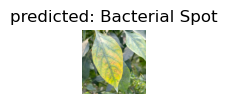

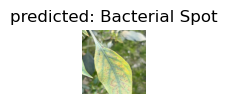

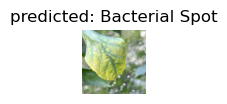

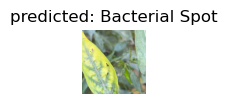

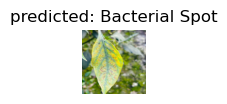

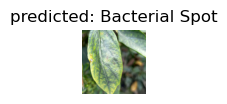

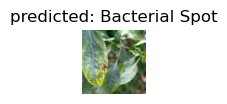

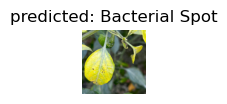

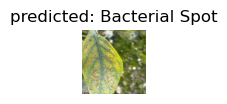

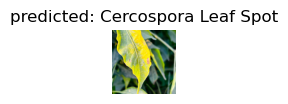

In [52]:
visualize_model(alexnet_trained_model,num_images=10)

In [ ]:
test_model(alexnet_trained_model)

In [54]:
torch.save(alexnet_trained_model.state_dict(), 'alexnet_trained_model.pth')

# Save the training history
history_path = 'alexnet_training_history.pth'
torch.save(history, history_path)